# Per unit

Per unit quantities, or pu for short, are non-dimensional units

### System Base/Power base ($S_b$)

$$
S_{\text{base}}
=
\text{base MVA}_{3\phi}
$$

### Voltage base ($V_b$)
$$
V_{\text{base}}
= {\text{base voltage, kV}_{LL}}
$$

### Base Impedance

$$
Z_{base} = \frac{V_{base}^2}{S_{base}} = \frac{\text{base voltage, k}V_{LL}^2}{\text{base MVA}_{3\phi}}
$$

$$
Z_{base} = \frac{V_{base_{LN}}}{I_{base}}
$$
### Per-Unit Impedance

$$
\text{Per-unit impedance of an element}
=
\frac{\text{actual impedance, }\Omega}
{\text{base impedance, }\Omega}
$$

### EXAMPLE 2.6
Solve example 2.4 by using per unit.
The terminal voltage of a Y-connected load consisting of three equal impedances of $20\angle30^{\circ}\Omega$ is 4.4 kV line to line. The impedance
of each of the three lines connecting the load to a bus at a substation is $Z_L = 1.4\angle75^{\circ}\Omega$.

Find the line-to-line voltage at the substation bus.

Load phase voltage = 2540.3 ∠0° V
Load current = 127.0 ∠-30.0° A
Line voltage drop = 177.8 ∠45.0° V
Substation phase voltage = 2669.0 ∠2.7° V
Substation line-line voltage = 4622.9 ∠32.7° V


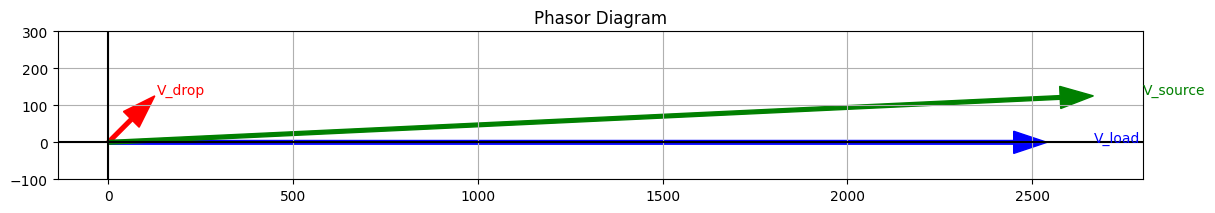

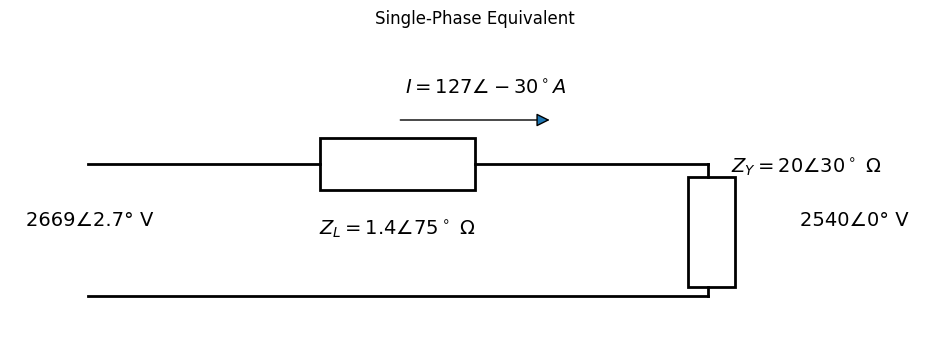

In [1]:
# TEST CELL
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

# variables
VLL_load = 4400
Z_load = cmath.rect(20, math.radians(30))
Z_line = cmath.rect(1.4, math.radians(75))

#load
V_phase_load_mag = VLL_load / math.sqrt(3)
V_phase_load = cmath.rect(V_phase_load_mag, 0)

#Il
I_line = V_phase_load / Z_load

# delta V
V_drop = I_line * Z_line

#V_ln
V_phase_source = V_phase_load + V_drop
V_phase_source_mag = abs(V_phase_source)
V_phase_source_ang = math.degrees(cmath.phase(V_phase_source))

#V_LL
VLL_source_mag = math.sqrt(3) * V_phase_source_mag
VLL_source_ang = V_phase_source_ang + 30

#res
print(f'Load phase voltage = {V_phase_load_mag:.1f} ∠0° V')
print(f'Load current = {abs(I_line):.1f} ∠{math.degrees(cmath.phase(I_line)):.1f}° A')
print(f'Line voltage drop = {abs(V_drop):.1f} ∠{math.degrees(cmath.phase(V_drop)):.1f}° V')
print(f'Substation phase voltage = {V_phase_source_mag:.1f} ∠{V_phase_source_ang:.1f}° V')
print(f'Substation line-line voltage = {VLL_source_mag:.1f} ∠{VLL_source_ang:.1f}° V')

#phasor plot
fig, ax = plt.subplots(figsize=(14,4))

def draw_phasor(z, color, label):
    ax.arrow(0,0,z.real,z.imag,color=color,width=10,
             head_width=60,length_includes_head=True)
    ax.text(z.real*1.05,z.imag*1.05,label,color=color)


draw_phasor(V_phase_load,'blue','V_load')
draw_phasor(V_drop,'red','V_drop')
draw_phasor(V_phase_source,'green','V_source')

ax.axhline(0,color='black')
ax.axvline(0,color='black')
ax.grid(True)
ax.set_ylim(-100, 300)
ax.set_aspect('equal')
ax.set_title('Phasor Diagram')
plt.show()

#per phase diagram
fig, ax = plt.subplots(figsize=(12,4))
ax.axis('off')

ax.plot([1,4],[2,2],'k',lw=2)
ax.plot([6,9],[2,2],'k',lw=2)
ax.plot([1,9],[0.5,0.5],'k',lw=2)
#vertical line
ax.plot([9,9],[2,1.85],'k',lw=2)
ax.plot([9,9],[0.5,0.6],'k',lw=2)


line_imp = Rectangle((4,1.7),2,0.6,fill=False,linewidth=2)
ax.add_patch(line_imp)

load_imp = Rectangle((8.75,0.6),0.6,1.25,fill=False,linewidth=2)
ax.add_patch(load_imp)

ax.text(5,1.2,r'$Z_L=1.4\angle75^\circ\ \Omega$',ha='center',fontsize=14)
ax.text(9.3,1.9,r'$Z_Y=20\angle30^\circ\ \Omega$',fontsize=14)

arrow = FancyArrowPatch((5,2.5),(7,2.5),arrowstyle='-|>',mutation_scale=20)
ax.add_patch(arrow)

ax.text(5.1,2.8,
        rf'$I={abs(I_line):.0f}\angle{math.degrees(cmath.phase(I_line)):.0f}^\circ A$',
        fontsize=14)

ax.text(0.2,1.3,
        rf'{V_phase_source_mag:.0f}∠{V_phase_source_ang:.1f}° V',fontsize=14)

ax.text(10.2,1.3,
        rf'{V_phase_load_mag:.0f}∠0° V',fontsize=14)

plt.title('Single-Phase Equivalent')
plt.xlim(0,12)
plt.ylim(0,3.5)
plt.show()


Zbase = (4400/sqrt(3))/127 = 20.0027 Ω
Base impedance is 20.0 Ω
Z = ZL_cp/Zbase = 0.0700 ∠ 75.00° per unit
The line impedance is 0.0700 ∠ 75.00° per unit
Ian_pu = Ian/Ibase = 1.00 ∠ -30.00° per unit
Van = 1 + Ian_pu*Z = 1.0507 ∠ 2.70° per unit
The line-to-neutral voltage at the substation Van is 1.0507 per unit with angle 2.70°
VLN = |Van| * Vbase/sqrt(3) = 2669.05 V
The magnitude of line-to-neutral voltage at the substation bus is 2669.05 V
VLL = |Van| * Vbase = 4622.92 V
The magnitude of line-to-line voltage at the substation bus is 4622.92 V


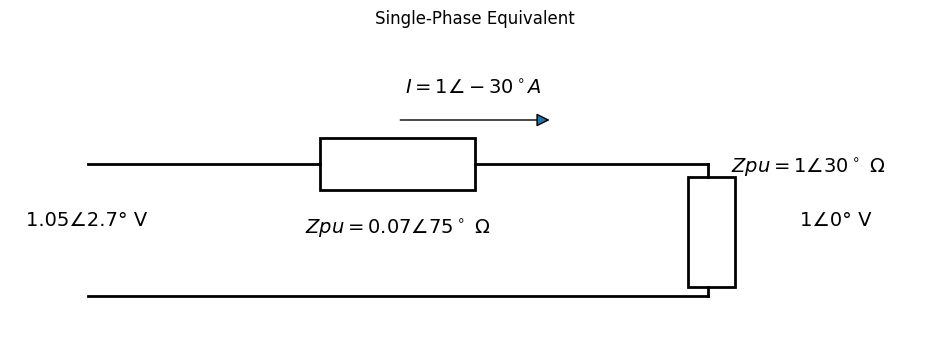

In [2]:
# TEST CELL
import cmath
import math

# Base values
Vbase = 4400      # V
Ibase = 127       # A

# Data from Example 2.3
Vline = 4400      # V
ZL = 1.4
ZL_angle = 75     # degrees

Zline = 20
Zline_angle = 30  # degrees


# polar to rectangular
ZL_cp = cmath.rect(ZL, math.radians(ZL_angle))
Zline_cp = cmath.rect(Zline, math.radians(Zline_angle))


#LN
Van = Vline / math.sqrt(3)

Ian = Van / Zline_cp

#Zbase

Zbase = (4400 / math.sqrt(3)) / 127

print(f"Zbase = (4400/sqrt(3))/127 = {Zbase:.4f} Ω")
print(f"Base impedance is {Zbase:.1f} Ω")

#Z

Z = ZL_cp / Zbase

Z_mag = abs(Z)
Z_ang = math.degrees(cmath.phase(Z))

print(f"Z = ZL_cp/Zbase = {Z_mag:.4f} ∠ {Z_ang:.2f}° per unit")
print(f"The line impedance is {Z_mag:.4f} ∠ {Z_ang:.2f}° per unit")

#pu current

Ian_pu = Ian / Ibase

I_mag = abs(Ian_pu)
I_ang = math.degrees(cmath.phase(Ian_pu))

print(f"Ian_pu = Ian/Ibase = {I_mag:.2f} ∠ {I_ang:.2f}° per unit")


#V_pu
Van_pu = complex(1, 0) + Ian_pu * Z

Van_mag = abs(Van_pu)
Van_ang = math.degrees(cmath.phase(Van_pu))

print(
    f"Van = 1 + Ian_pu*Z = "
    f"{Van_mag:.4f} ∠ {Van_ang:.2f}° per unit"
)

print(
    f"The line-to-neutral voltage at the substation "
    f"Van is {Van_mag:.4f} per unit "
    f"with angle {Van_ang:.2f}°"
)

#real values

VLN = Van_mag * Vbase / math.sqrt(3)

print(f"VLN = |Van| * Vbase/sqrt(3) = {VLN:.2f} V")
print(
    f"The magnitude of line-to-neutral voltage "
    f"at the substation bus is {VLN:.2f} V"
)

VLL = Van_mag * Vbase

print(f"VLL = |Van| * Vbase = {VLL:.2f} V")
print(
    f"The magnitude of line-to-line voltage "
    f"at the substation bus is {VLL:.2f} V"
)

#per phase diagram
fig, ax = plt.subplots(figsize=(12,4))
ax.axis('off')

ax.plot([1,4],[2,2],'k',lw=2)
ax.plot([6,9],[2,2],'k',lw=2)
ax.plot([1,9],[0.5,0.5],'k',lw=2)
#vertical line
ax.plot([9,9],[2,1.85],'k',lw=2)
ax.plot([9,9],[0.5,0.6],'k',lw=2)

line_imp = Rectangle((4,1.7),2,0.6,fill=False,linewidth=2)
ax.add_patch(line_imp)

load_imp = Rectangle((8.75,0.6),0.6,1.25,fill=False,linewidth=2)
ax.add_patch(load_imp)

ax.text(5,1.2,r'$Zpu=0.07\angle75^\circ\ \Omega$',ha='center',fontsize=14)
ax.text(9.3,1.9,r'$Zpu=1\angle30^\circ\ \Omega$',fontsize=14)

arrow = FancyArrowPatch((5,2.5),(7,2.5),arrowstyle='-|>',mutation_scale=20)
ax.add_patch(arrow)

ax.text(5.1,2.8,
        rf'$I={abs(Ian_pu):.0f}\angle{math.degrees(cmath.phase(I_line)):.0f}^\circ A$',
        fontsize=14)

ax.text(0.2,1.3,
        rf'{Van_mag:.2f}∠{Van_ang:.1f}° V',fontsize=14)

ax.text(10.2,1.3,
        rf'{1}∠{0}° V',fontsize=14)

plt.title('Single-Phase Equivalent')
plt.xlim(0,12)
plt.ylim(0,3.5)
plt.show()

## Changing the Base of Per-Unit Quantities
To change from per-unit impedance on a given base to per-unit impedance on a new
base, the following equation applies:

$$
Z_{pu_{new}} = Z_{pu_{given}} \bigg(\frac{base kV_{given}}{base kV_{new}}\bigg)^2 \bigg(\frac{base MVA_{new}}{base MVA_{given}}\bigg)
$$

Per-Unit Reactance Base Conversion

The reactance of a generator designated X″ is given as 0.25 per unit based on
the generator’s nameplate rating of 18 kV, 500 MVA. The base for calculations
is 20 kV, 100 MVA. Find X″ on the new base.

Given:
    X_old = 0.25 p.u.
    
    S_old = 500 MVA
    
    V_old = 18 kV

    S_new = 100 MVA
    
    V_new = 20 kV

Formula:
    X_new = X_old * (V_old / V_new)^2 * (S_new / S_old) 
$$
X_{pu_{new}} = X_{pu_{given}} \bigg(\frac{V_{given}}{V_{new}}\bigg)^2 \bigg(\frac{S_{new}}{S_{given}}\bigg)
$$
Calculation:
    X_new = 0.25* (18 / 20)^2  * (100 / 500) 
    
    X_new = 0.25 * 0.2 * 0.81
    
    X_new = 0.0405 p.u.

Answer:
    X'' on the new base (20 kV, 100 MVA) = 0.0405 p.u.

Python Code:

In [4]:
X_old = 0.25
S_old = 500.0
V_old = 18.0

S_new = 100.0
V_new = 20.0

X_new = X_old  * (V_old / V_new)**2 * (S_new / S_old)

print(f"New reactance = {X_new:.4f} p.u.")


New reactance = 0.0405 p.u.
